In [64]:
import numpy as np
import pandas as pd
import math
from scipy import stats
from sklearn.preprocessing import MinMaxScaler


import matplotlib.pyplot as plt

from SALib.sample import saltelli
from SALib.analyze import sobol

In [51]:
plt.rcParams['figure.dpi'] = 200
plt.style.use('seaborn-v0_8-notebook')
plt.rc("font", 
       family="serif")
plt.rc("axes.spines", top=True, right=True)
# set explicit fontsizes for ticks, lables, legend and title
plt.rc('xtick', labelsize=16)
plt.rc('ytick', labelsize=16)
plt.rc('axes', labelsize=18)
plt.rc('legend', fontsize=8)
plt.rc('figure', titlesize=18)
# set gridlines and grid alpha and grid linestyle
plt.rc('axes', grid=True)
plt.rc('grid', linestyle='--')
plt.rc('grid', alpha=0.8)

In [10]:
def sample_borehole_data(n_samples=1000):
    # Define the distributions for each variable
    r_w = np.random.normal(loc=0.10, scale=0.0161812, size=n_samples)
    r = np.random.lognormal(mean=7.71, sigma=1.0056, size=n_samples)
    T_u = np.random.uniform(63070, 115600, size=n_samples)
    H_u = np.random.uniform(990, 1110, size=n_samples)
    T_l = np.random.uniform(63.1, 116, size=n_samples)
    H_l = np.random.uniform(700, 820, size=n_samples)
    L = np.random.uniform(1120, 1680, size=n_samples)
    K_w = np.random.uniform(9855, 12045, size=n_samples)

    # Combine the samples into a DataFrame
    data = pd.DataFrame({
        'r_w': r_w,
        'r': r,
        'T_u': T_u,
        'H_u': H_u,
        'T_l': T_l,
        'H_l': H_l,
        'L': L,
        'K_w': K_w
    })
    
    return data

# Generate 1000 samples from the joint distribution
data = sample_borehole_data(1000)
data.head()

,r_w,r,T_u,H_u,T_l,H_l,L,K_w
0,0.083685,1211.432101,89513.951212,1054.885981,88.901742,716.189746,1635.014629,10668.936573
1,0.073792,581.106528,91233.874172,996.806247,64.515105,785.083256,1438.857342,10643.225936
2,0.118941,4242.698862,74145.702908,1029.903197,102.578297,756.489526,1179.798699,9974.559528
3,0.082168,2013.042303,105083.310776,1016.740433,85.092036,727.348373,1610.561891,11838.353987
4,0.105255,1893.542264,76461.197628,1089.349974,100.903845,738.522321,1625.465236,11984.496950


In [72]:
class Borehole:
    def __init__(self, seed=42):
        self.rw_dist = stats.norm(loc=0.1, scale=0.0161812)
        self.r_dist = stats.lognorm(s=1.0056, scale=np.exp(7.71))
        self.Tu_dist = stats.uniform(63070, 115600)
        self.Hu_dist = stats.uniform(990, 1110)
        self.Tl_dist = stats.uniform(63.1, 116)
        self.Hl_dist = stats.uniform(700, 820)
        self.L_dist = stats.uniform(1120, 1680)
        self.Kw_dist = stats.uniform(9855, 12045)
        self.random_seed = seed

    def sample(self, n_samples=1000):
        """
        Borehole function: response is water flow through borehole in m^3 per year.

        Parameters:
        rw: radius of borehole in m
        r:  radius of influence in m
        Tu: transmissivity of upper aquifer in m^2/year
        Hu: potentiometric head of upper aquifer in m
        Tl: transmissivity of lower aquifer in m^2/year
        Hl: potentiometric head of lower aquifer in m
        Lth:  length of borehole in m
        Kw: hydraulic conductivity of borehole in m/year

        Use distribution objects defined in __init__ to sample n_samples from each parameter distribution. Then compute the water flow rate and return as a numpy array.
        """
        np.random.seed(self.random_seed)
        rw_samples = self.rw_dist.rvs(n_samples)
        r_samples = self.r_dist.rvs(n_samples)
        Tu_samples = self.Tu_dist.rvs(n_samples)
        Hu_samples = self.Hu_dist.rvs(n_samples)
        Tl_samples = self.Tl_dist.rvs(n_samples)
        Hl_samples = self.Hl_dist.rvs(n_samples)
        L_samples = self.L_dist.rvs(n_samples)
        Kw_samples = self.Kw_dist.rvs(n_samples)

        #         input_data = pd.DataFrame({
        #         'r_w': rw_samples,
        #         'r': r_samples,
        #         'T_u': Tu_samples,
        #         'H_u': Hu_samples,
        #         'T_l': Tl_samples,
        #         'H_l': Hl_samples,
        #         'L': L_samples,
        #         'K_w': Kw_samples
        #         })

        
        input_data = np.core.records.fromarrays(
        [rw_samples, 
         r_samples, 
         Tu_samples, 
         Hu_samples, 
         Tl_samples,
         Hl_samples, 
         L_samples, 
         Kw_samples],
        names='r_w, r, T_u, H_u, T_l, H_l, L, K_w'
        )
        
        return input_data
    
    def scale_data(self, X):
        scaler = MinMaxScaler()
        data_array = np.array([X[name] for name in X.dtype.names]).T
        scaled_data = scaler.fit_transform(data_array)
        scaled_data = np.core.records.fromarrays(
        scaled_data_array.T, names=X.dtype.names
        )
        return scaled_data
    
    def evaluate1(self, X):
        """
        In the style of test functions from SALib, take in a
        numpy array with variables in specific order
        """
        n_samples = X.shape[0]
        Q = np.zeros(n_samples)
        for i in range(n_samples):
            numerator = 2 * math.pi * X['T_u'][i] * (X['H_u'][i] - X['H_l'][i])

            denom1 = np.log(X['r'][i] / X['r_w'][i])
            denom2 = 2 * X['L'][i] * X['T_u'][i] / (X['K_w'][i] * X['r'][i]**2)
            denom3 = X['T_u'][i] / X['T_l'][i]

            Q[i] = numerator / (denom1 * (1 + (denom2 / denom1) + denom3))

        return Q
    
    
    def evaluate2(self, X):
        """
        Pass in a regular numpy array instead of recarray in the following
        order of variables: ['r_w', 'r', 'T_u', 'H_u', 'T_l', 'H_l', 'L', 'K_w']
        """
        
        n_samples = X.shape[0]
        Q = np.zeros(n_samples)
        for i in range(n_samples):
            numerator = 2 * math.pi * X[i, 2] * (X[i, 3] - X[i, 5])

            denom1 = np.log(X[i, 1] / X[i, 0])
            denom2 = 2 * X[i, 6] * X[i, 2] / (X[i, 7] * X[i, 1]**2)
            denom3 = X[i, 2] / X[i, 4]

            Q[i] = numerator / (denom1 * (1 + (denom2 / denom1) + denom3))

        return Q

In [73]:
bh = Borehole(seed=47)
bh_inputs = bh.sample(10000)

In [74]:
bh_inputs['r_w'].shape

(10000,)

In [75]:
bh_inputs.shape

(10000,)

In [76]:
bh_output = bh.evaluate1(bh_inputs)

In [77]:
bh_output.shape

(10000,)

In [78]:
def plot_2d_contours(input_data, output_data,
                    xvar='r_w', yvar='r'):
    n_samples = output_data.shape[0]

    x = input_data[xvar]
    y = input_data[yvar]

    plt.figure(figsize=(8, 6))
    plt.tricontourf(x, y, output_data, 
                    levels=20, 
                    cmap='coolwarm')
    plt.colorbar(label='Borehole Flow Rate')
    plt.xlabel(r"${}$".format(xvar))
    plt.ylabel(r"${}$".format(yvar))
    plt.title('Borehole Function Contours')
    plt.show()

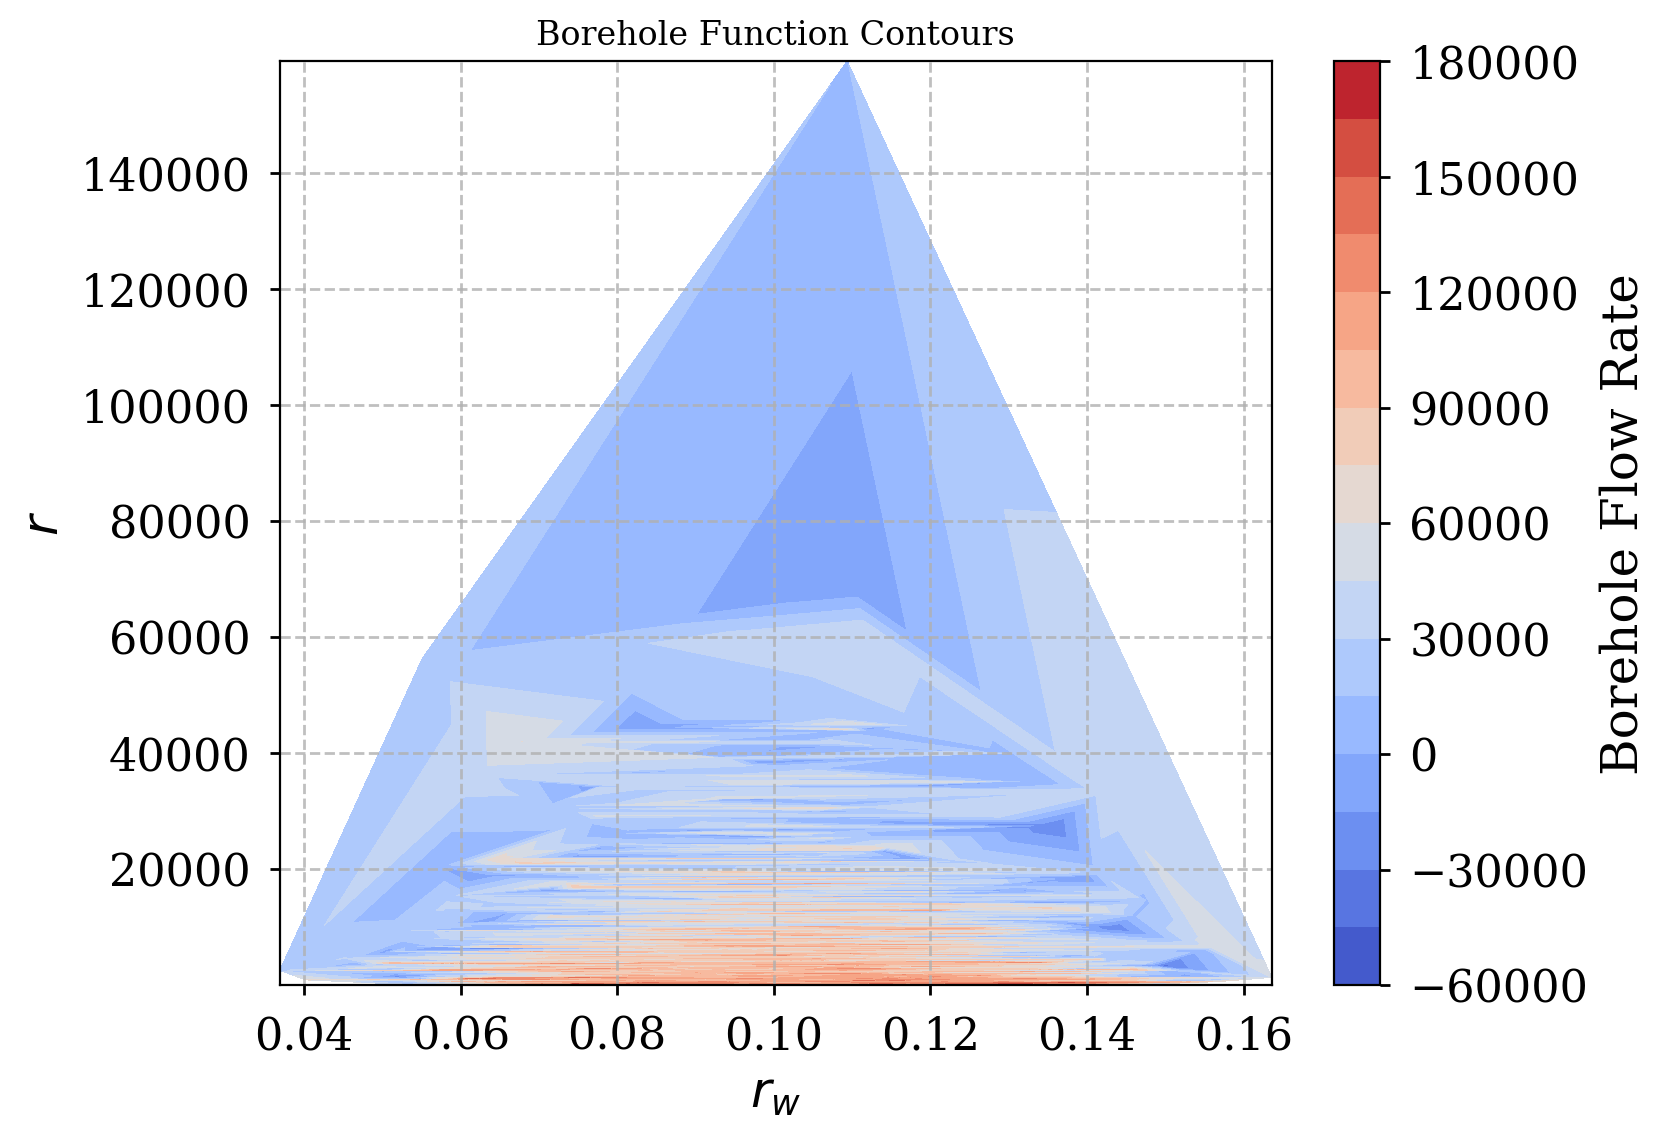

In [79]:
plot_2d_contours(bh_inputs, bh_output)

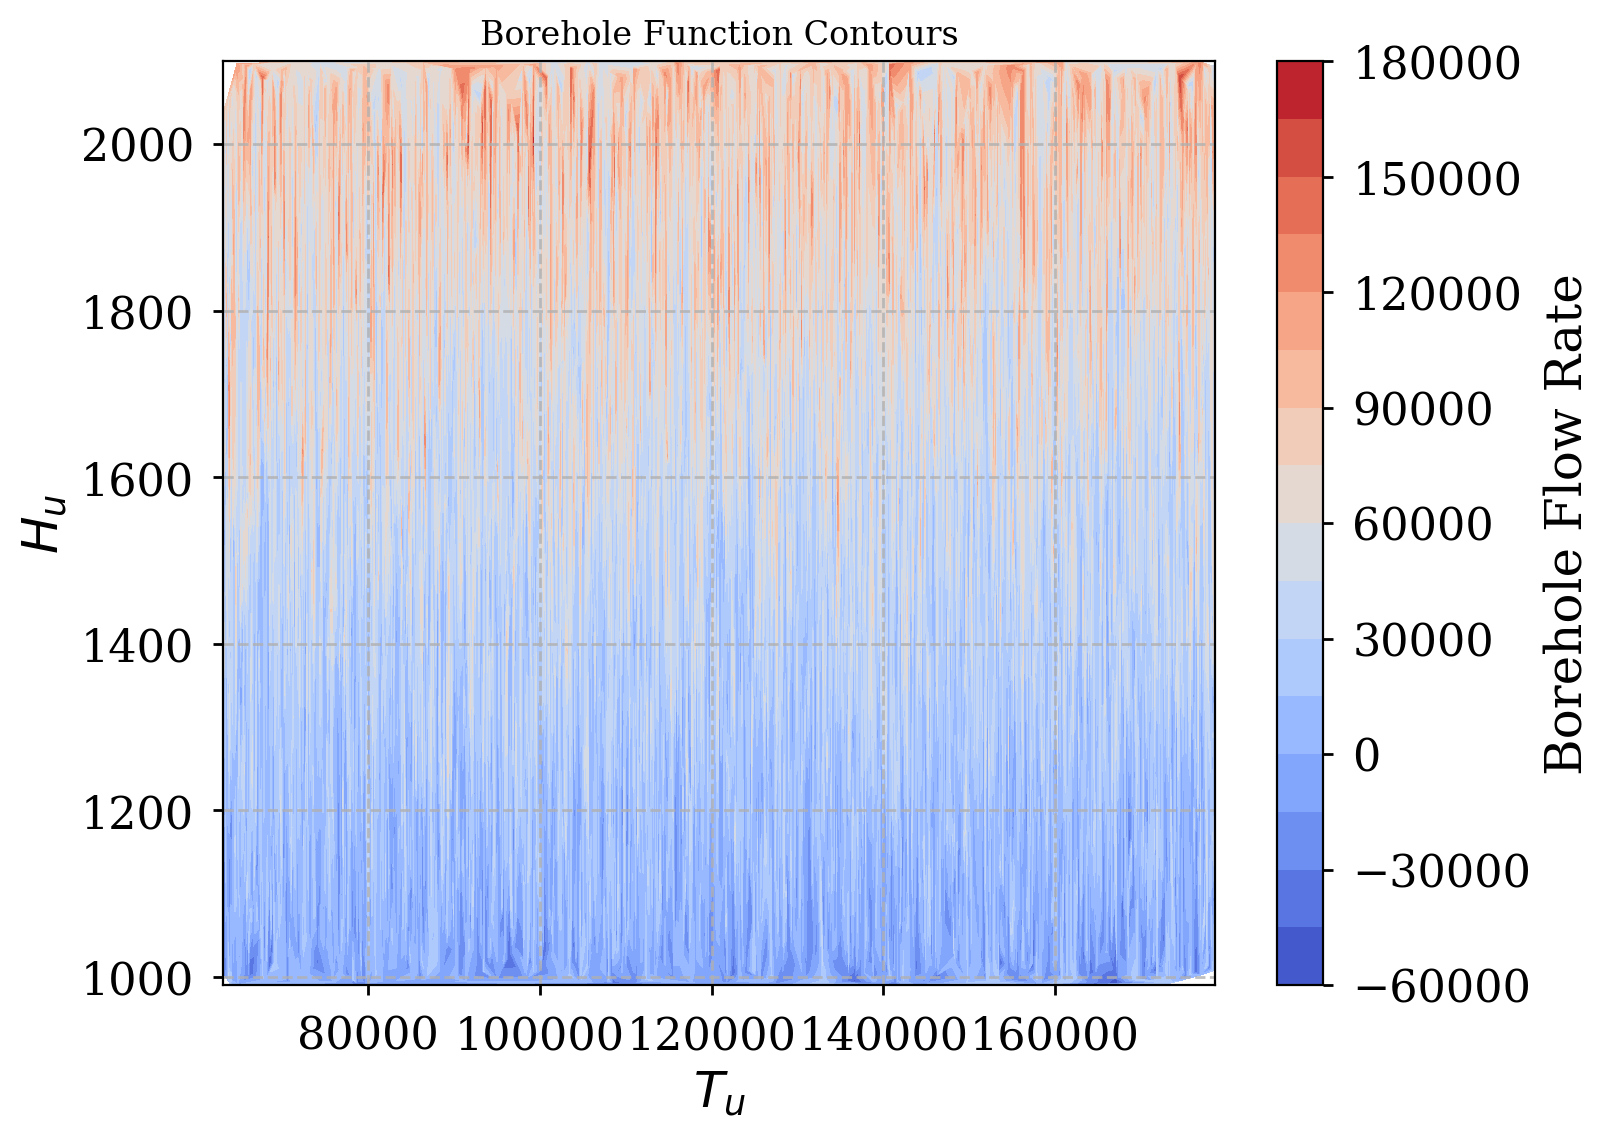

In [80]:
plot_2d_contours(bh_inputs, bh_output, xvar='T_u', yvar='H_u')

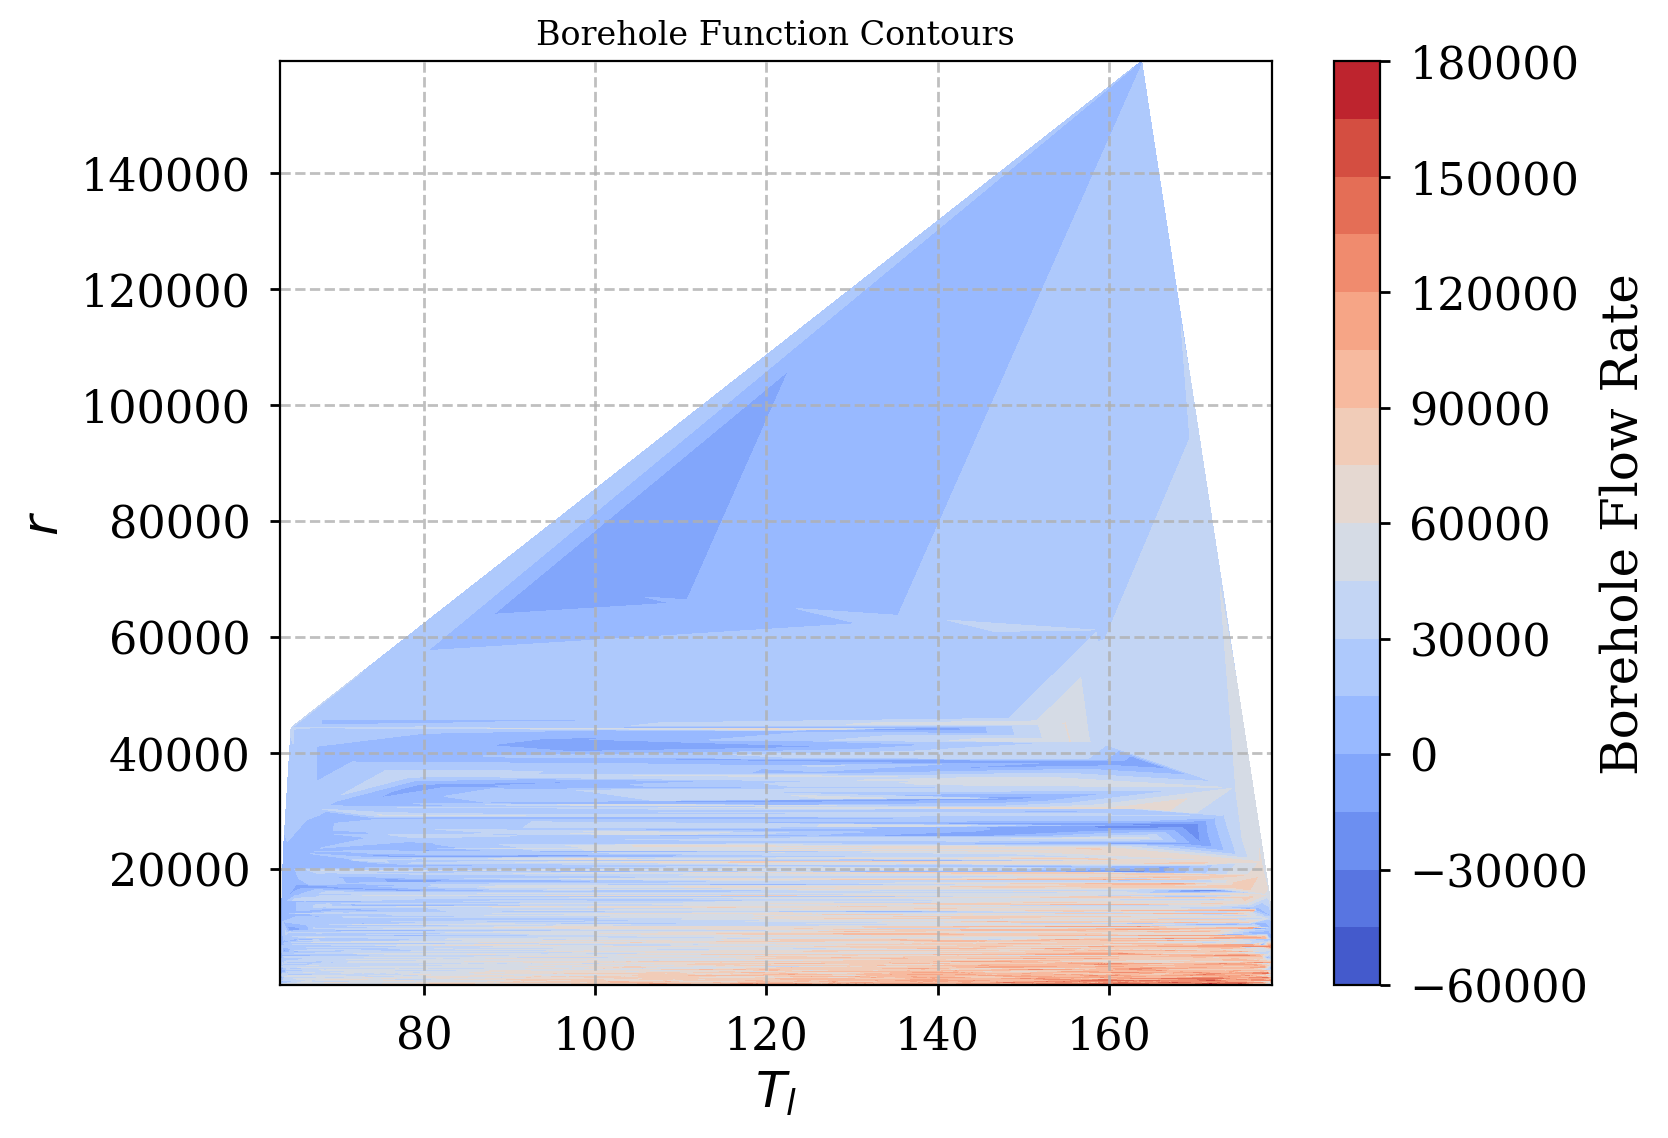

In [81]:
plot_2d_contours(bh_inputs, bh_output, xvar='T_l', yvar='r')

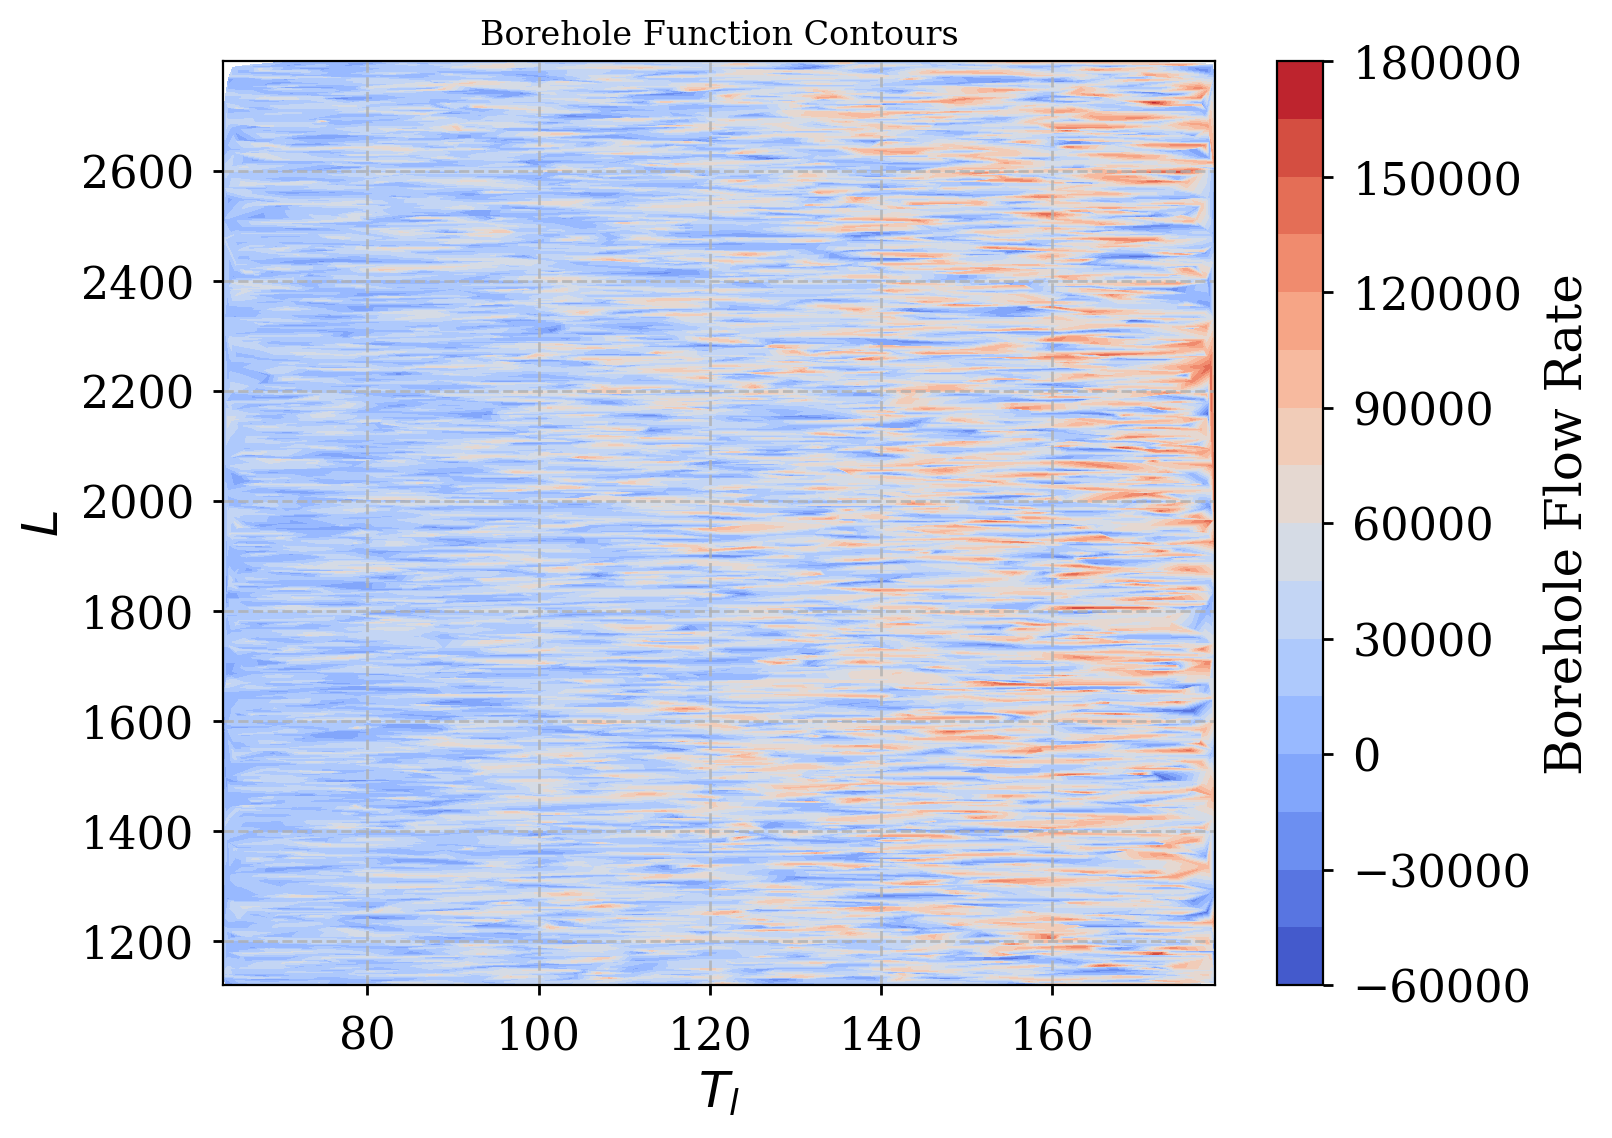

In [82]:
plot_2d_contours(bh_inputs, bh_output, xvar='T_l', yvar='L')

In [83]:
bh_output.min()

-53383.0446669191

In [84]:
np.log(40000/0.04)

13.815510557964274

Define problem, draw samples from low-discrepancy sequence, and perform sensitivity analysis

In [85]:
problem = {
    'num_vars': 8,
    'names': ['r_w', 'r', 'T_u', 'H_u', 'T_l', 'H_l', 'L', 'K_w'],
    'bounds': [[0.05, 0.15],
              [100, 50000],
              [63070, 115600],
              [990, 1110],
              [63.1, 116],
              [700, 820],
              [1120, 1680],
              [9855, 12045]]
}

If we ask for $N$ samples, the sampler will return $N * (2D + 2)$ samples, where $D$ is the number of model inputs.

In [86]:
param_values = saltelli.sample(problem, 2048)

/var/folders/0m/401pb5hj7y59vbxjhd49jjj80000gp/T/ipykernel_29037/2996815261.py:1: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5. Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, 2048)


In [87]:
param_values.shape

(36864, 8)

In [88]:
Y = bh.evaluate2(param_values)
Y.shape

(36864,)

In [89]:
Si = sobol.analyze(problem, Y)

In [90]:
print(Si['S1'])

[ 9.11182883e-03  1.33943437e-01  3.88745258e-06  2.08452463e-01
  4.21206710e-01  2.08755024e-01  4.96443146e-08 -5.87974576e-08]


In [91]:
print(Si['ST'])

[1.03235999e-02 1.38088054e-01 5.81392272e-07 2.17229918e-01
 4.41084482e-01 2.16149030e-01 3.66512373e-11 7.26072450e-12]


In [93]:
print("x1-x2:", Si['S2'][0,1])
print("x1-x3:", Si['S2'][0,2])
print("x2-x3:", Si['S2'][1,2])

x1-x2: 0.0012373676208839723
x1-x3: 0.0004101997161895186
x2-x3: -0.006546579203180892


In [94]:
total_Si, first_Si, second_Si = Si.to_df()

array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

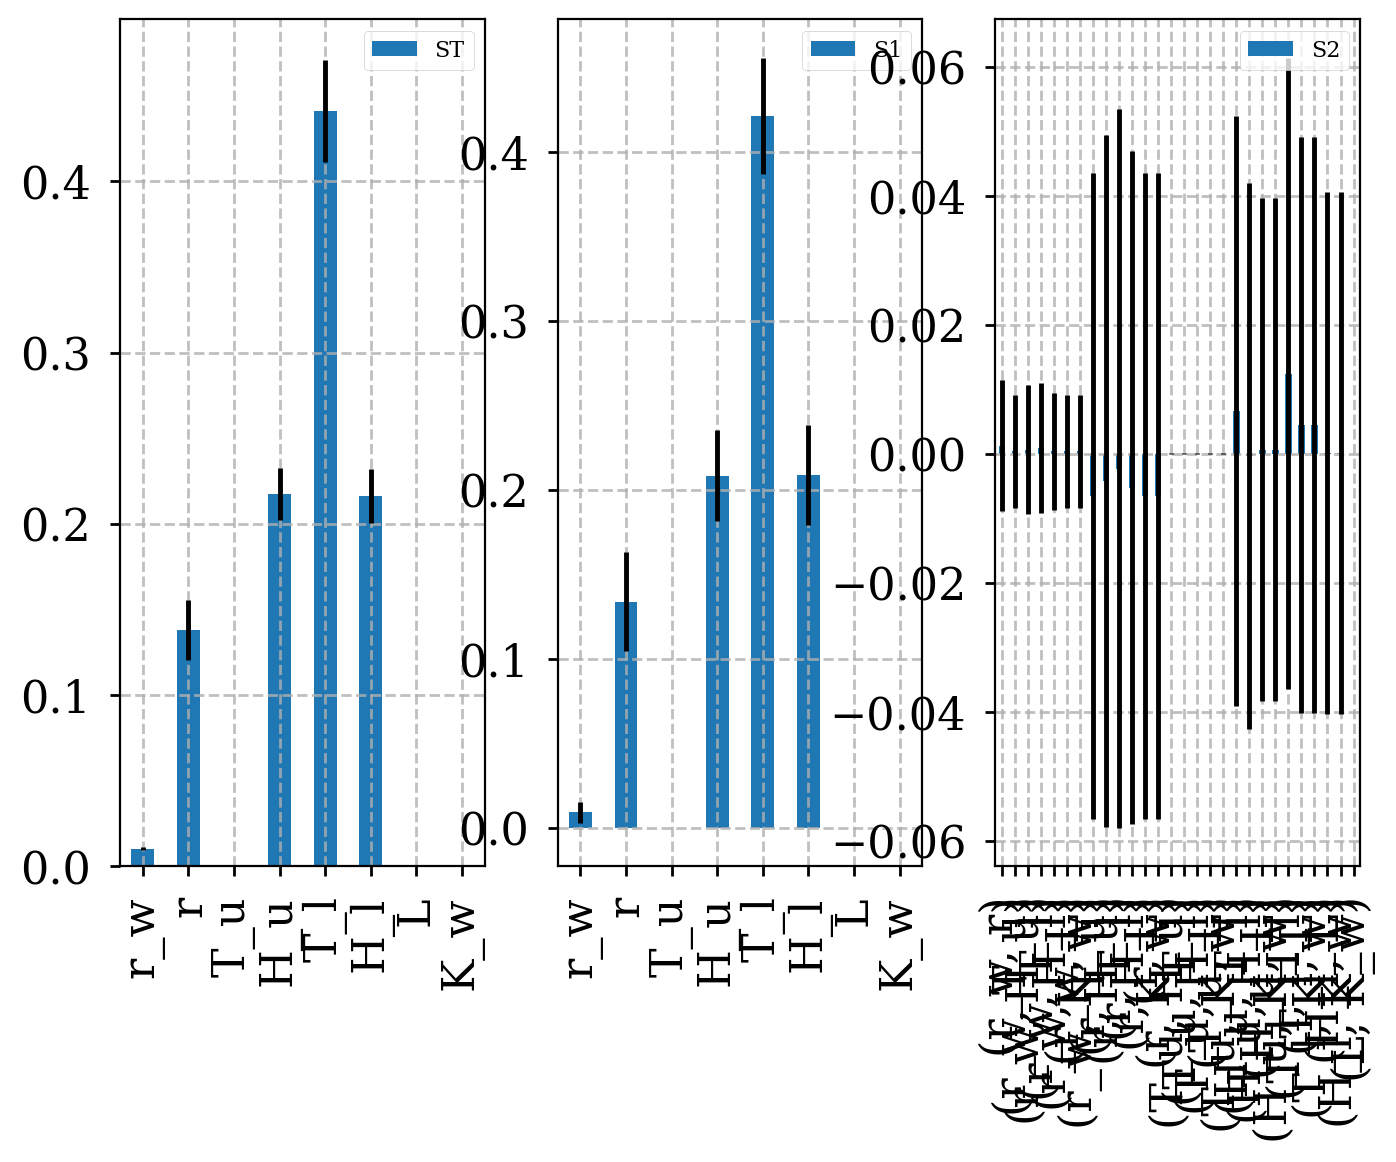

In [95]:
Si.plot()